Here we have the following changes
1. We have added the physiological features such as the age and gender

In [1]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Cell 2: Load Data (Base Biomarkers + Demographics/Genetics)
# Replace 'adnimerge.csv' with your actual file path
df = pd.read_csv('adnimerge.csv')

target_col = 'DX'

# We bring in Age, Gender, and the APOE4 gene to provide context to the CSF numbers
base_features = ['AGE', 'PTGENDER', 'APOE4', 'ABETA', 'TAU', 'PTAU']

df_model3 = df[['RID', 'VISCODE', target_col] + base_features].copy()

print(f"Initial shape: {df_model3.shape}")

Initial shape: (16421, 9)


In [3]:
# Cell 3: Data Cleaning & Feature Engineering

# 1. Drop rows missing the target diagnosis
df_model3 = df_model3.dropna(subset=[target_col])

# 2. Convert CSF markers to numeric (forces text values to NaN)
for col in ['ABETA', 'TAU', 'PTAU']:
    df_model3[col] = pd.to_numeric(df_model3[col], errors='coerce')

# 3. Drop rows that are missing ANY of the core CSF data
df_model3 = df_model3.dropna(subset=['ABETA', 'TAU', 'PTAU'], how='any')

# 4. ENCODE CATEGORICALS: Convert 'PTGENDER' to numeric (Male=0, Female=1)
df_model3['PTGENDER'] = df_model3['PTGENDER'].map({'Male': 0, 'Female': 1})

# 5. FEATURE ENGINEERING: Create the crucial protein ratios
df_model3['TAU_ABETA_Ratio'] = df_model3['TAU'] / df_model3['ABETA']
df_model3['PTAU_ABETA_Ratio'] = df_model3['PTAU'] / df_model3['ABETA']

# Define our final, upgraded feature list
final_features3 = [
    'AGE', 'PTGENDER', 'APOE4', 
    'ABETA', 'TAU', 'PTAU', 
    'TAU_ABETA_Ratio', 'PTAU_ABETA_Ratio'
]

# Drop any remaining rows that might be missing Age or APOE4
df_model3 = df_model3.dropna(subset=final_features3)

print("Class distribution for target (DX) AFTER feature engineering:")
print(df_model3[target_col].value_counts())

# Define X3 and y3
X3 = df_model3[final_features3]
y3 = df_model3[target_col]

Class distribution for target (DX) AFTER feature engineering:
DX
MCI         916
CN          578
Dementia    509
Name: count, dtype: int64


In [4]:
# Cell 4: Splitting and Scaling
# Split the upgraded data
X_train3, X_test3, y_train3, y_test3 = train_test_split(X3, y3, test_size=0.20, random_state=42, stratify=y3)

# Scale the features
scaler3 = StandardScaler()
X_train_scaled3 = scaler3.fit_transform(X_train3)
X_test_scaled3 = scaler3.transform(X_test3)

print(f"Training features shape: {X_train_scaled3.shape}")

Training features shape: (1602, 8)


In [5]:
# Cell 5: Initialize and Train the Upgraded Model
rf_classifier3 = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Train the model
rf_classifier3.fit(X_train_scaled3, y_train3)

print("Model 3 training complete.")

Model 3 training complete.


Accuracy Score: 0.5411471321695761

Classification Report:
               precision    recall  f1-score   support

          CN       0.59      0.47      0.53       116
    Dementia       0.51      0.49      0.50       102
         MCI       0.54      0.61      0.57       183

    accuracy                           0.54       401
   macro avg       0.54      0.53      0.53       401
weighted avg       0.54      0.54      0.54       401



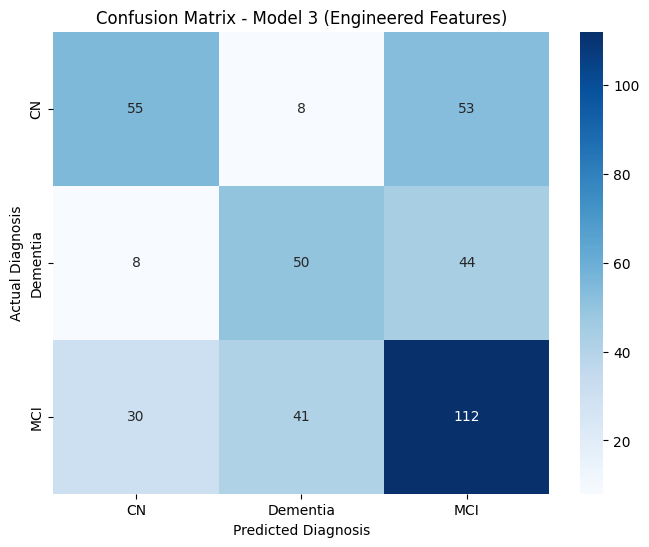

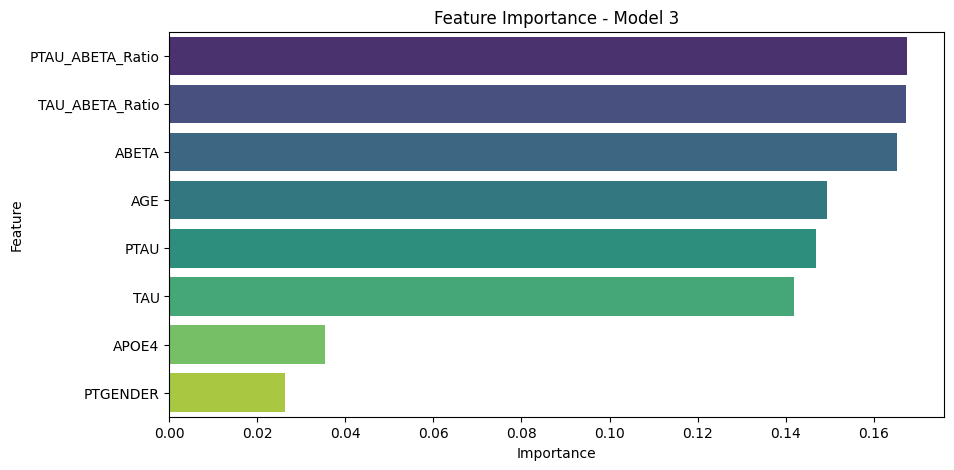

In [6]:
# Cell 6: Predictions and Evaluation
# Make predictions
y_pred3 = rf_classifier3.predict(X_test_scaled3)

# Print metrics
print("Accuracy Score:", accuracy_score(y_test3, y_pred3))
print("\nClassification Report:\n", classification_report(y_test3, y_pred3))

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
cm3 = confusion_matrix(y_test3, y_pred3, labels=rf_classifier3.classes_)
sns.heatmap(cm3, annot=True, fmt='d', cmap='Blues', 
            xticklabels=rf_classifier3.classes_, 
            yticklabels=rf_classifier3.classes_)
plt.title('Confusion Matrix - Model 3 (Engineered Features)')
plt.xlabel('Predicted Diagnosis')
plt.ylabel('Actual Diagnosis')
plt.show()

# Plot Feature Importance
feature_importances3 = rf_classifier3.feature_importances_
importance_df3 = pd.DataFrame({
    'Feature': final_features3,
    'Importance': feature_importances3
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=importance_df3, palette='viridis')
plt.title('Feature Importance - Model 3')
plt.show()